# Week 8 · Day 2 — Practice
# Evaluate Like a Pro 🔍

In class we cleaned the Titanic and compared two models. Now you practice the **evaluation** skills on a fresh, **all-numeric** dataset — the **Breast Cancer** dataset from scikit-learn (each row is a tumor; predict *benign* vs *malignant* from measurements).

Because it's already clean and numeric, you can focus purely on **train → predict → evaluate**.

Fill in every `# YOUR CODE HERE`. Run as you go.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
cancer = data.frame
print("Shape:", cancer.shape)
cancer.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


The target column is called `target` (0 = malignant, 1 = benign).

### Step 1 — X and y
- `X` = all columns **except** `target`
- `y` = the `target` column

In [8]:
cancer

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [9]:
X = cancer[["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]]
y = cancer["mean concavity"]
print("X shape:", X.shape, "| y shape:", y.shape)

X shape: (569, 5) | y shape: (569,)


### Step 2 — Train / test split (20% test, random_state=42)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 455 | Test: 114


In [11]:
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])
print(X_train.isnull().sum())
print(X_train.dtypes)

Train: 455 | Test: 114
mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object


In [12]:
print("Train:", y_train.shape[0], "| Test:", y_test.shape[0])
print(y_train.isnull().sum())
print(y_train.dtypes)
print(y_train.unique())

Train: 455 | Test: 114
0
float64
[0.313    0.2487   0.05988  0.02379  0.01084  0.1639   0.1362   0.03503
 0.03885  0.1411   0.06015  0.1572   0.169    0.02948  0.02181  0.1657
 0.3001   0.255    0.02475  0.01583  0.05892  0.2077   0.0858   0.04831
 0.09966  0.118    0.03046  0.1479   0.01923  0.0226   0.1445   0.04057
 0.1698   0.164    0.05375  0.01055  0.05253  0.02109  0.01588  0.03974
 0.01633  0.4264   0.2049   0.       0.03346  0.01369  0.08422  0.001597
 0.103    0.04686  0.06335  0.03653  0.04105  0.1307   0.1357   0.1374
 0.02881  0.08092  0.145    0.03873  0.02974  0.02891  0.06505  0.02853
 0.06895  0.05385  0.02783  0.04132  0.09447  0.1491   0.09366  0.1009
 0.06664  0.2032   0.06126  0.1323   0.03609  0.0683   0.02399  0.0802
 0.04751  0.01652  0.2229   0.02712  0.01447  0.09252  0.2107   0.02556
 0.1921   0.1272   0.03344  0.00751  0.09293  0.05285  0.04358  0.03996
 0.04063  0.1218   0.06476  0.03193  0.02363  0.03546  0.01342  0.1293
 0.06824  0.1525   0.1722   0.039  

In [13]:
df = cancer.copy()
print(df.columns.tolist())

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


### Step 3 — Train a KNN model (n_neighbors=5) and predict

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### Step 4 — Confusion matrix heatmap

Build the confusion matrix for the KNN predictions and draw it as a heatmap (labels: `Malignant`, `Benign`).

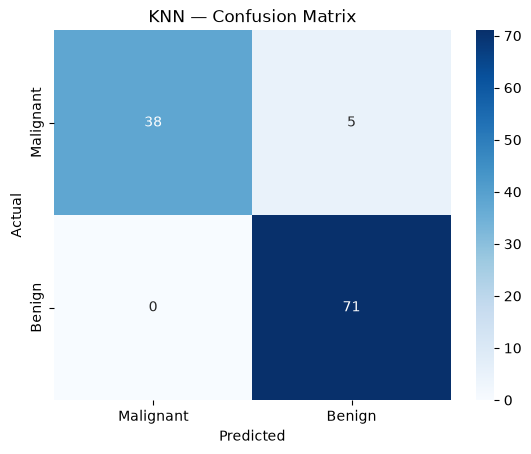

In [19]:
cm = confusion_matrix(y_test, knn.predict(X_test))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant", "Benign"],
            yticklabels=["Malignant", "Benign"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("KNN — Confusion Matrix")
plt.show()

In [25]:
knn_preds = knn.predict(X_test)

### Step 5 — Compare with Logistic Regression

Train a `LogisticRegression(max_iter=5000)` on the **same split**, predict, and print both accuracies. Which won?

In [ ]:
logreg = # YOUR CODE HERE
# fit
# YOUR CODE HERE
logreg_preds = # YOUR CODE HERE

print("KNN accuracy:               ", round(accuracy_score(y_test, knn_preds)*100, 1), "%")
print("Logistic Regression accuracy:", round(accuracy_score(y_test, logreg_preds)*100, 1), "%")

In [26]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
# fit
logreg.fit(X_train, y_train)

logreg_preds = logreg.predict(X_test)

print("KNN accuracy:", round(accuracy_score(y_test, knn_preds)*100, 1), "%")
print("Logistic Regression accuracy:", round(accuracy_score(y_test, logreg_preds)*100, 1), "%")

KNN accuracy: 95.6 %
Logistic Regression accuracy: 95.6 %


### 🧠 Reflect (write below)

Look at your confusion matrix. In a cancer test, which mistake is more dangerous — calling a **malignant** tumor *benign*, or calling a **benign** tumor *malignant*? Why does accuracy alone not capture this?

Double-click and write 2–3 sentences.

*Your answer:*

Cancer test mein sabse khatarnak mistake wo hai jab malignant tumor ko benign bata diya jaye (False Negative) — kyunke patient ko lagega wo theek hai jabke usay urgent treatment ki zaroorat hoti hai, aur bimari phel jati hai. Benign ko malignant kehna (False Positive) bhi ghalat hai lekin usme sirf extra tests hote hain, jaan ka khatra nahi hota. Accuracy akeli yeh farq nahi bata sakti kyunke wo sirf total correct predictions ginti hai — is liye confusion matrix aur recall jaise metrics dekhna zaroori hai."


